# Random Search


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_data, split_features_target
from src.optimization import random_search
from src.objective import CVConfig

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "train.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = load_data(path=DATA_PATH)
X, y = split_features_target(df)

print("Data loaded successfully:", X.shape)

Data loaded successfully: (200000, 200)


In [3]:
results = random_search(
    X,
    y,
    n_iter=20,
    seed=42,
    cfg=CVConfig(),
)

results.to_csv(
    RESULTS_DIR / "random_search_results.csv",
    index=False,
)

display(
    results.sort_values(
        by="value",
        ascending=False,
    ).head()
)

,trial,method,value,cv_std,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
10,11,random_search,0.883793,0.002999,691,0.087620,33,12,130,0.693576,0.529151,1.406919,2.935938
7,8,random_search,0.883209,0.003905,500,0.047983,24,11,11,0.914770,0.832425,3.525827,7.807290
5,6,random_search,0.881504,0.003211,588,0.034685,30,9,77,0.690764,0.834907,2.185760,8.326782
4,5,random_search,0.881260,0.003047,451,0.139779,26,12,115,0.987004,0.662913,1.852299,4.695558
6,7,random_search,0.879480,0.001813,497,0.069350,92,10,127,0.921906,0.693739,1.441641,6.824955


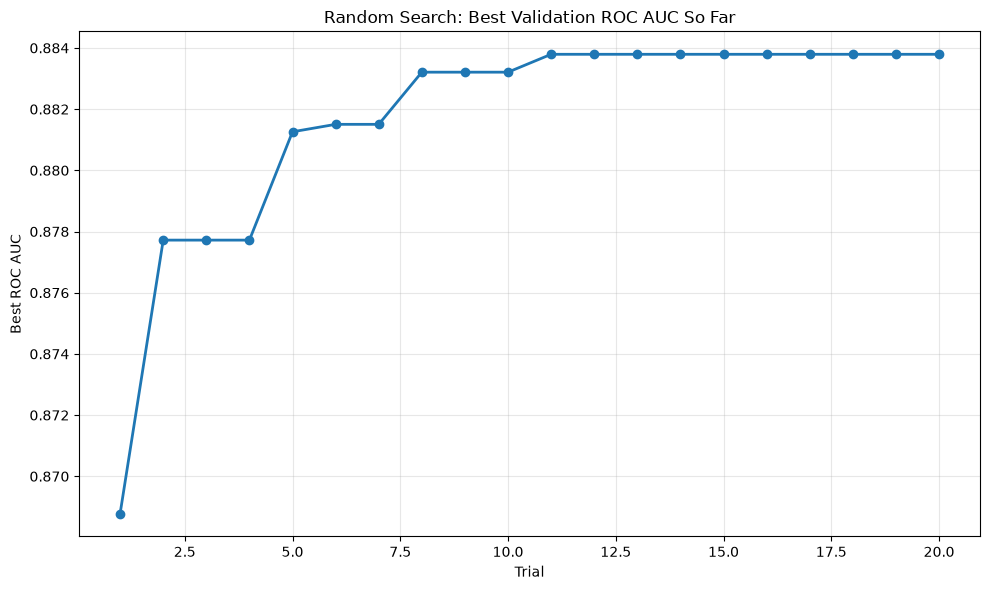

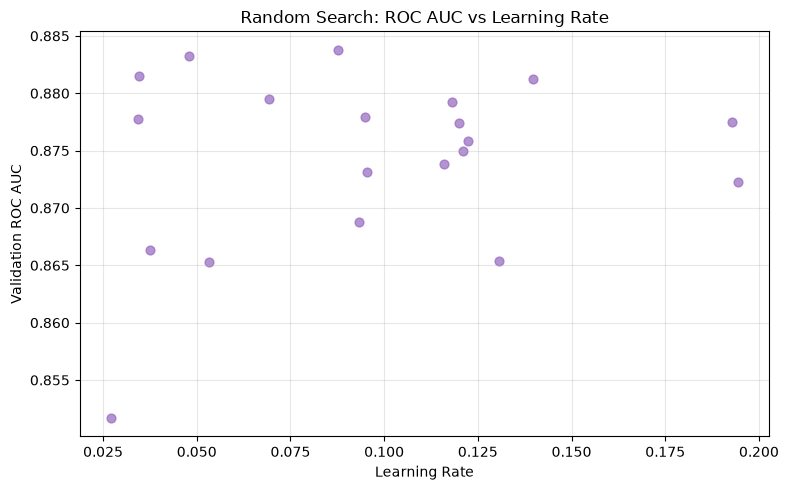

,trial,value,best_so_far,learning_rate
0,1,0.868783,0.868783,0.093387
1,2,0.877720,0.877720,0.034342
2,3,0.865262,0.877720,0.053175
3,4,0.872240,0.877720,0.194433
4,5,0.881260,0.881260,0.139779
5,6,0.881504,0.881504,0.034685
6,7,0.879480,0.881504,0.069350
7,8,0.883209,0.883209,0.047983
8,9,0.879251,0.883209,0.118061
9,10,0.865360,0.883209,0.130596


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RESULTS_PATH = PROJECT_ROOT / "results" / "random_search_results.csv"

if "results" not in globals():
    if RESULTS_PATH.exists():
        results = pd.read_csv(RESULTS_PATH)
    else:
        raise FileNotFoundError(
            "No results DataFrame found. Run the previous cell first, or generate the CSV from the random-search step."
        )

results = results.sort_values(by="trial").reset_index(drop=True)
results["best_so_far"] = results["value"].cummax()

plt.figure(figsize=(10, 6))
plt.plot(
    results["trial"],
    results["best_so_far"],
    marker="o",
    linewidth=2,
    color="tab:blue",
)
plt.title("Random Search: Best Validation ROC AUC So Far")
plt.xlabel("Trial")
plt.ylabel("Best ROC AUC")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    results["learning_rate"],
    results["value"],
    alpha=0.7,
    s=40,
    color="tab:purple",
)
plt.title("Random Search: ROC AUC vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Validation ROC AUC")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

results[["trial", "value", "best_so_far", "learning_rate"]].head(10)
